🔬 MODÈLE PRÉDICTIF DE DÉTECTION PRÉCOCE DU DT1

📊 Dimensions du dataset:
   Nombre d'échantillons: 1000
   Nombre de variables: 7
   Distribution des classes:
      - Sains (0): 750 (75.0%)
      - DT1 (1): 250 (25.0%)

✅ Aucune valeur manquante

📂 Division des données:
   Entraînement: 750 échantillons (75%)
   Test: 250 échantillons (25%)

⚙️ Normalisation appliquée (StandardScaler)
   → Moyenne = 0, Écart-type = 1 pour chaque variable

🎯 SÉLECTION DES VARIABLES LES PLUS IMPORTANTES

📊 Scores d'importance des variables (F-test):
        Variable    Score_F  p-value
3          HbA1c  1775.8991      0.0
2  glycemie_jeun  1762.0279      0.0
5          ESCO2   520.4302      0.0
4     ANP32A_IT1   292.1486      0.0
6          NBPF1   181.5996      0.0
0            age   115.7649      0.0
1            IMC    95.7689      0.0


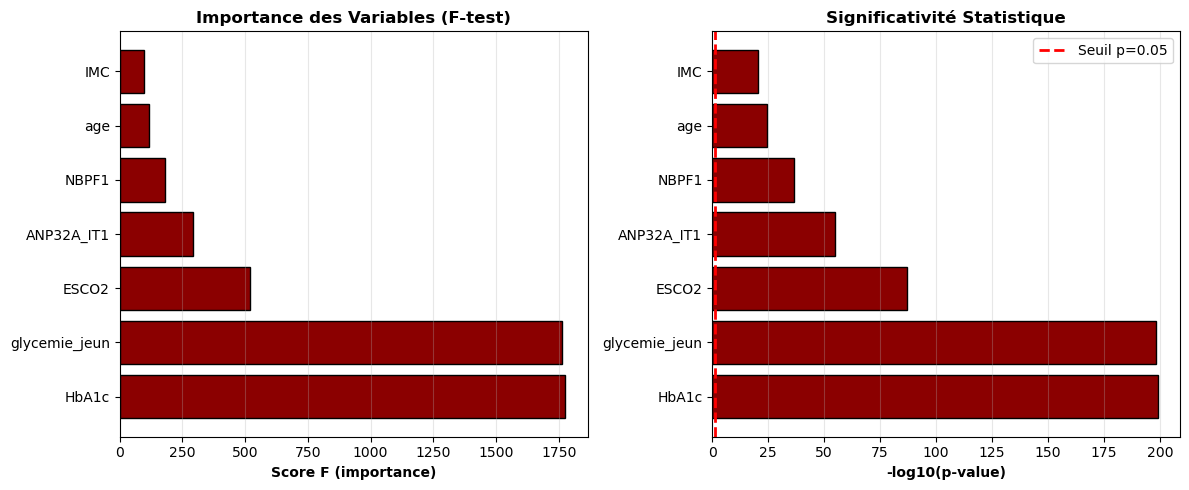


🤖 ENTRAÎNEMENT DE 4 MODÈLES DE MACHINE LEARNING

🔄 Entraînement: Logistic Regression...
   ✅ Accuracy Test: 0.992
   ✅ F1-Score: 0.984
   ✅ CV Accuracy: 0.992 ± 0.003

🔄 Entraînement: Random Forest...
   ✅ Accuracy Test: 1.000
   ✅ F1-Score: 1.000
   ✅ CV Accuracy: 0.996 ± 0.003

🔄 Entraînement: Gradient Boosting...
   ✅ Accuracy Test: 1.000
   ✅ F1-Score: 1.000
   ✅ CV Accuracy: 0.993 ± 0.007

🔄 Entraînement: SVM...
   ✅ Accuracy Test: 1.000
   ✅ F1-Score: 1.000
   ✅ CV Accuracy: 0.993 ± 0.007

📊 COMPARAISON DES PERFORMANCES

             Modèle  Accuracy Test  F1-Score  CV Accuracy   CV Std
      Random Forest          1.000  1.000000     0.996000 0.003266
  Gradient Boosting          1.000  1.000000     0.993333 0.007303
                SVM          1.000  1.000000     0.993333 0.007303
Logistic Regression          0.992  0.983871     0.992000 0.002667


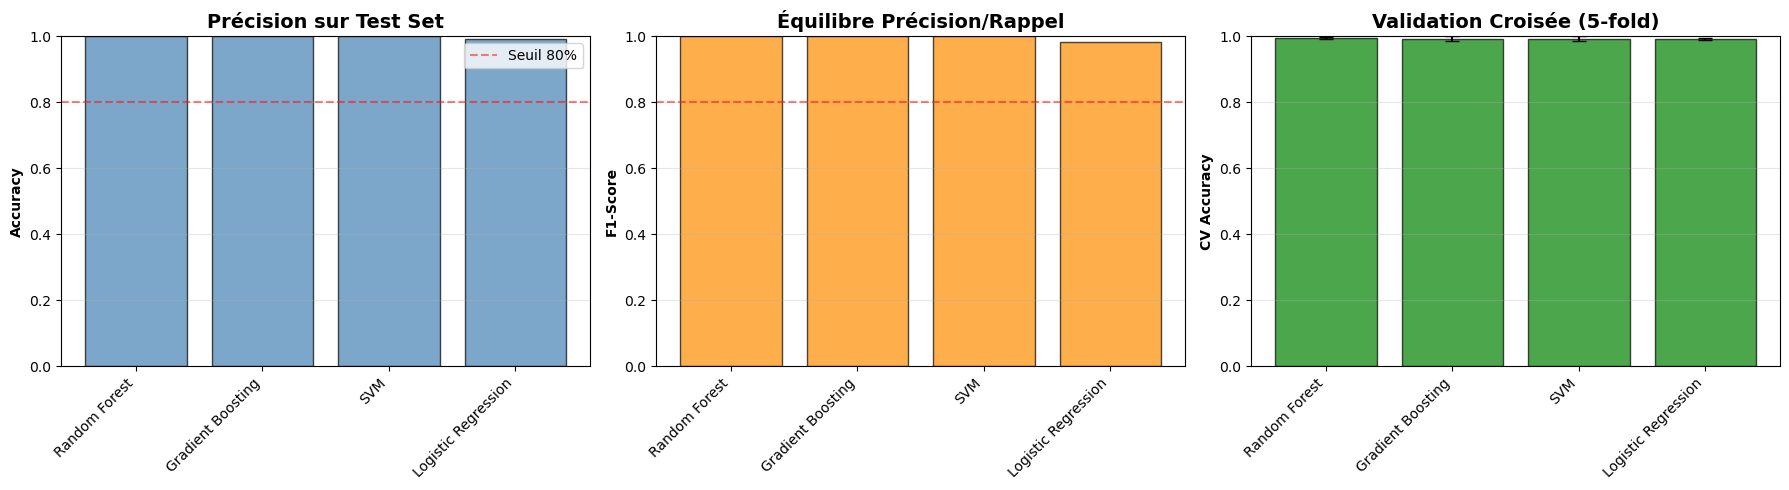


🏆 MEILLEUR MODÈLE: Random Forest
   Accuracy: 1.000

🔍 ANALYSE DÉTAILLÉE: Random Forest

📊 Matrice de Confusion:
[[188   0]
 [  0  62]]

📋 Rapport de Classification:
              precision    recall  f1-score   support

    Sain (0)       1.00      1.00      1.00       188
     DT1 (1)       1.00      1.00      1.00        62

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



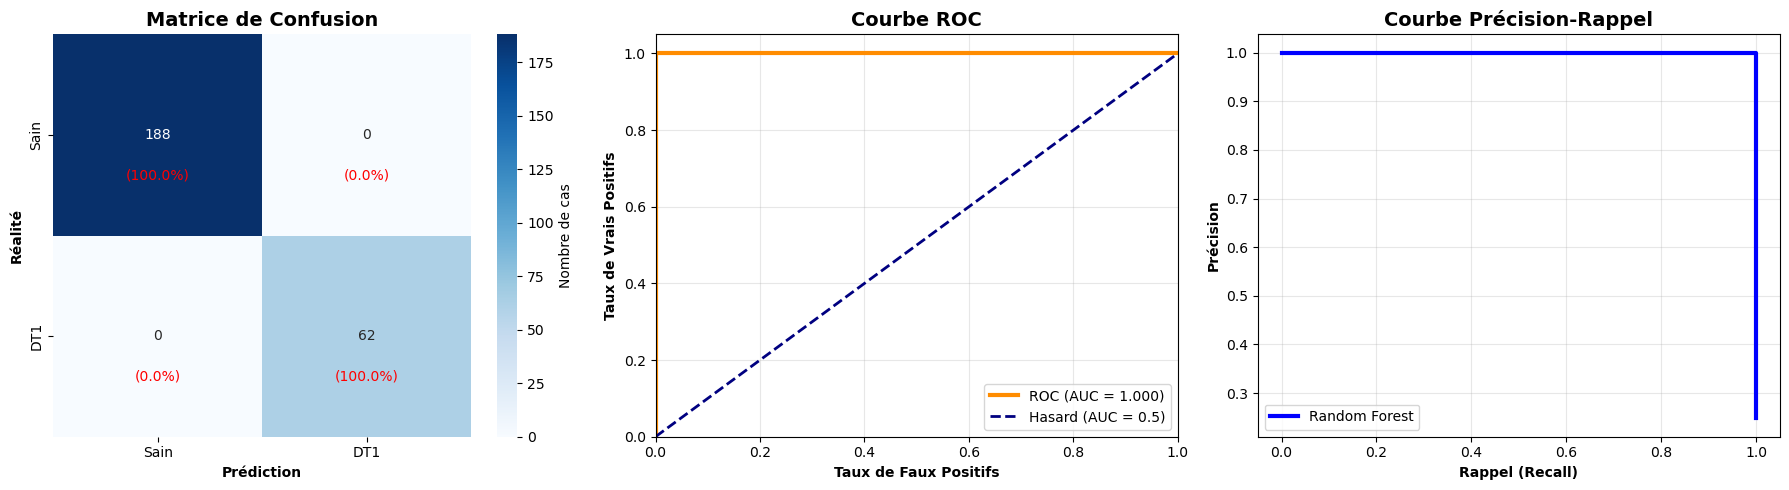


🌳 IMPORTANCE DES VARIABLES SELON LE MODÈLE

     Variable  Importance
        HbA1c    0.363883
glycemie_jeun    0.341171
        ESCO2    0.132242
   ANP32A_IT1    0.070024
        NBPF1    0.061323
          IMC    0.017304
          age    0.014052


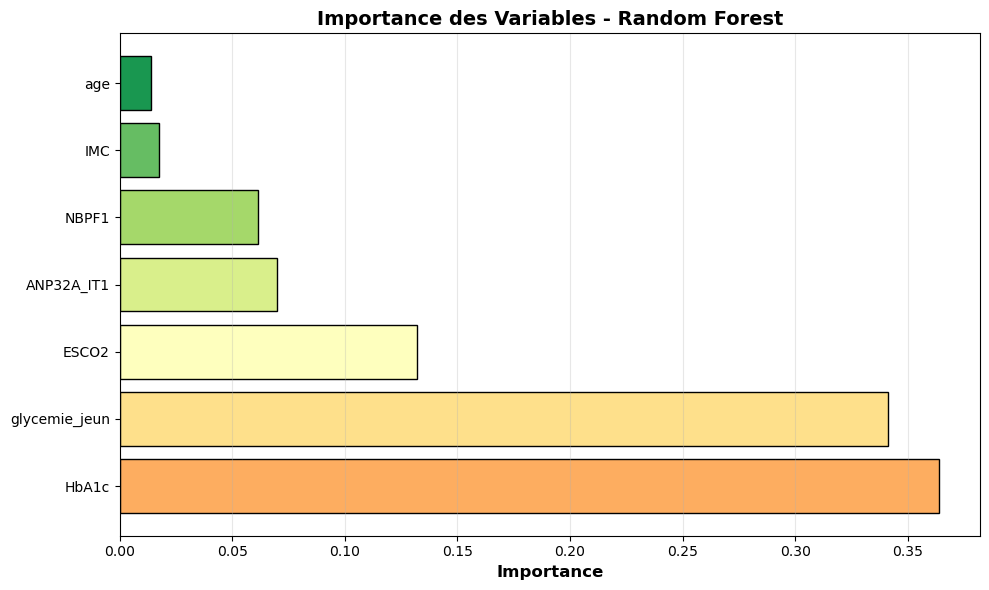


🩺 OUTIL DE PRÉDICTION POUR NOUVEAUX PATIENTS

💡 Exemple de prédiction pour 3 patients:

Patient A (Risque élevé):
   Prédiction: DT1
   Probabilité DT1: 58.0%
   Niveau de Risque: 🟡 MODÉRÉ
   Recommandation: Surveillance régulière (contrôle dans 1-3 mois)

Patient B (Risque modéré):
   Prédiction: DT1
   Probabilité DT1: 58.0%
   Niveau de Risque: 🟡 MODÉRÉ
   Recommandation: Surveillance régulière (contrôle dans 1-3 mois)

Patient C (Risque faible):
   Prédiction: DT1
   Probabilité DT1: 56.0%
   Niveau de Risque: 🟡 MODÉRÉ
   Recommandation: Surveillance régulière (contrôle dans 1-3 mois)

✅ MODÈLE PRÊT À L'EMPLOI !

💡 Pour prédire un nouveau patient:
   resultat = predire_risque_dt1({
       'age': 50, 'IMC': 28, 'glycemie_jeun': 115,
       'HbA1c': 6.2, 'ANP32A_IT1': -1.0,
       'ESCO2': 0.5, 'NBPF1': -0.5
   })


In [2]:
# ═══════════════════════════════════════════════════════════════════
# MODÈLE PRÉDICTIF DE DÉTECTION PRÉCOCE DU DIABÈTE TYPE 1 (DT1)
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, accuracy_score, 
                             precision_recall_curve, f1_score)
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 1 : PRÉPARATION DES DONNÉES
# ═══════════════════════════════════════════════════════════════════

print("="*70)
print("🔬 MODÈLE PRÉDICTIF DE DÉTECTION PRÉCOCE DU DT1")
print("="*70)

# Définir les variables prédictives
variables_cles = ['age', 'IMC', 'glycemie_jeun', 'HbA1c', 
                  'ANP32A_IT1', 'ESCO2', 'NBPF1']
df = pd.read_csv('../2_DONNEES/processed/dataset_clean.csv')
# Séparer les features (X) et la cible (y)
X = df[variables_cles]
y = df['diagnostic']

print(f"\n📊 Dimensions du dataset:")
print(f"   Nombre d'échantillons: {X.shape[0]}")
print(f"   Nombre de variables: {X.shape[1]}")
print(f"   Distribution des classes:")
print(f"      - Sains (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"      - DT1 (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

# Vérifier les valeurs manquantes
if X.isnull().sum().sum() > 0:
    print("\n⚠️ Valeurs manquantes détectées - Imputation nécessaire")
    X = X.fillna(X.mean())
else:
    print("\n✅ Aucune valeur manquante")

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 2 : DIVISION DES DONNÉES (Train/Test)
# ═══════════════════════════════════════════════════════════════════

# Stratified split pour garder les proportions de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\n📂 Division des données:")
print(f"   Entraînement: {X_train.shape[0]} échantillons ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"   Test: {X_test.shape[0]} échantillons ({X_test.shape[0]/X.shape[0]*100:.0f}%)")

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 3 : NORMALISATION DES DONNÉES
# ═══════════════════════════════════════════════════════════════════

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n⚙️ Normalisation appliquée (StandardScaler)")
print("   → Moyenne = 0, Écart-type = 1 pour chaque variable")

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 4 : SÉLECTION DES MEILLEURES VARIABLES
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("🎯 SÉLECTION DES VARIABLES LES PLUS IMPORTANTES")
print("="*70)

# Test ANOVA F-test pour chaque variable
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

# Créer un DataFrame avec les scores
feature_scores = pd.DataFrame({
    'Variable': variables_cles,
    'Score_F': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('Score_F', ascending=False)

print("\n📊 Scores d'importance des variables (F-test):")
print(feature_scores.round(4))

# Visualisation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors_importance = ['darkred' if p < 0.001 else 'red' if p < 0.01 
                     else 'orange' if p < 0.05 else 'gray' 
                     for p in feature_scores['p-value']]
plt.barh(feature_scores['Variable'], feature_scores['Score_F'], 
         color=colors_importance, edgecolor='black')
plt.xlabel('Score F (importance)', fontweight='bold')
plt.title('Importance des Variables (F-test)', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.subplot(1, 2, 2)
plt.barh(feature_scores['Variable'], -np.log10(feature_scores['p-value']), 
         color=colors_importance, edgecolor='black')
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', 
            linewidth=2, label='Seuil p=0.05')
plt.xlabel('-log10(p-value)', fontweight='bold')
plt.title('Significativité Statistique', fontweight='bold')
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 5 : ENTRAÎNEMENT DE PLUSIEURS MODÈLES
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("🤖 ENTRAÎNEMENT DE 4 MODÈLES DE MACHINE LEARNING")
print("="*70)

# Définir les modèles
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, 
                                            max_depth=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, 
                                                     random_state=42, 
                                                     max_depth=3),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

# Stocker les résultats
results = {}

for name, model in models.items():
    print(f"\n🔄 Entraînement: {name}...")
    
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                 cv=cv, scoring='accuracy')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"   ✅ Accuracy Test: {accuracy:.3f}")
    print(f"   ✅ F1-Score: {f1:.3f}")
    print(f"   ✅ CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 6 : COMPARAISON DES MODÈLES
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 COMPARAISON DES PERFORMANCES")
print("="*70)

comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Accuracy Test': [r['accuracy'] for r in results.values()],
    'F1-Score': [r['f1_score'] for r in results.values()],
    'CV Accuracy': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()]
}).sort_values('Accuracy Test', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1: Accuracy
axes[0].bar(comparison_df['Modèle'], comparison_df['Accuracy Test'], 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Précision sur Test Set', fontweight='bold', fontsize=14)
axes[0].set_ylim([0, 1])
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Seuil 80%')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Graphique 2: F1-Score
axes[1].bar(comparison_df['Modèle'], comparison_df['F1-Score'], 
            color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_ylabel('F1-Score', fontweight='bold')
axes[1].set_title('Équilibre Précision/Rappel', fontweight='bold', fontsize=14)
axes[1].set_ylim([0, 1])
axes[1].axhline(y=0.8, color='red', linestyle='--', alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Graphique 3: Cross-Validation avec barres d'erreur
axes[2].bar(comparison_df['Modèle'], comparison_df['CV Accuracy'], 
            yerr=comparison_df['CV Std'], color='green', 
            edgecolor='black', alpha=0.7, capsize=5)
axes[2].set_ylabel('CV Accuracy', fontweight='bold')
axes[2].set_title('Validation Croisée (5-fold)', fontweight='bold', fontsize=14)
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Identifier le meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
best_model = results[best_model_name]['model']

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.3f}")

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 7 : ANALYSE DÉTAILLÉE DU MEILLEUR MODÈLE
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print(f"🔍 ANALYSE DÉTAILLÉE: {best_model_name}")
print("="*70)

y_pred_best = results[best_model_name]['y_pred']
y_pred_proba_best = results[best_model_name]['y_pred_proba']

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
print("\n📊 Matrice de Confusion:")
print(cm)

# Rapport de classification
print("\n📋 Rapport de Classification:")
print(classification_report(y_test, y_pred_best, 
                           target_names=['Sain (0)', 'DT1 (1)']))

# Visualisation de la matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sain', 'DT1'], 
            yticklabels=['Sain', 'DT1'],
            cbar_kws={'label': 'Nombre de cas'},
            ax=axes[0])
axes[0].set_xlabel('Prédiction', fontweight='bold')
axes[0].set_ylabel('Réalité', fontweight='bold')
axes[0].set_title('Matrice de Confusion', fontweight='bold', fontsize=14)

# Ajouter les pourcentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        axes[0].text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='red')

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=3, 
            label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
            label='Hasard (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taux de Faux Positifs', fontweight='bold')
axes[1].set_ylabel('Taux de Vrais Positifs', fontweight='bold')
axes[1].set_title('Courbe ROC', fontweight='bold', fontsize=14)
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# Courbe Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
axes[2].plot(recall, precision, color='blue', lw=3, 
            label=f'{best_model_name}')
axes[2].set_xlabel('Rappel (Recall)', fontweight='bold')
axes[2].set_ylabel('Précision', fontweight='bold')
axes[2].set_title('Courbe Précision-Rappel', fontweight='bold', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 8 : IMPORTANCE DES VARIABLES (pour Random Forest/GB)
# ═══════════════════════════════════════════════════════════════════

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("\n" + "="*70)
    print("🌳 IMPORTANCE DES VARIABLES SELON LE MODÈLE")
    print("="*70)
    
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Variable': variables_cles,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\n" + feature_importance_df.to_string(index=False))
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance_df)))
    plt.barh(feature_importance_df['Variable'], 
             feature_importance_df['Importance'],
             color=colors_imp, edgecolor='black')
    plt.xlabel('Importance', fontweight='bold', fontsize=12)
    plt.title(f'Importance des Variables - {best_model_name}', 
             fontweight='bold', fontsize=14)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════════════
# ÉTAPE 9 : FONCTION DE PRÉDICTION POUR NOUVEAUX PATIENTS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("🩺 OUTIL DE PRÉDICTION POUR NOUVEAUX PATIENTS")
print("="*70)

def predire_risque_dt1(patient_data, seuil_risque=0.5):
    """
    Prédit le risque de DT1 pour un nouveau patient
    
    Parameters:
    -----------
    patient_data : dict ou DataFrame
        Dictionnaire avec les variables: age, IMC, glycemie_jeun, etc.
    seuil_risque : float
        Seuil de probabilité pour alerter (par défaut 0.5)
    
    Returns:
    --------
    dict : Résultats de la prédiction
    """
    # Convertir en DataFrame si nécessaire
    if isinstance(patient_data, dict):
        patient_df = pd.DataFrame([patient_data])
    else:
        patient_df = patient_data
    
    # Vérifier les colonnes
    colonnes_manquantes = set(variables_cles) - set(patient_df.columns)
    if colonnes_manquantes:
        return {"Erreur": f"Colonnes manquantes: {colonnes_manquantes}"}
    
    # Normaliser
    patient_scaled = scaler.transform(patient_df[variables_cles])
    
    # Prédiction
    prediction = best_model.predict(patient_scaled)[0]
    probabilite = best_model.predict_proba(patient_scaled)[0, 1]
    
    # Interprétation
    if probabilite >= 0.8:
        niveau_risque = "🔴 TRÈS ÉLEVÉ"
        recommandation = "Consultation endocrinologue URGENTE"
    elif probabilite >= 0.6:
        niveau_risque = "🟠 ÉLEVÉ"
        recommandation = "Tests complémentaires recommandés sous 1 semaine"
    elif probabilite >= 0.4:
        niveau_risque = "🟡 MODÉRÉ"
        recommandation = "Surveillance régulière (contrôle dans 1-3 mois)"
    else:
        niveau_risque = "🟢 FAIBLE"
        recommandation = "Suivi normal annuel"
    
    return {
        'Prédiction': 'DT1' if prediction == 1 else 'Sain',
        'Probabilité DT1': f"{probabilite:.1%}",
        'Niveau de Risque': niveau_risque,
        'Recommandation': recommandation
    }

# Exemple d'utilisation
print("\n💡 Exemple de prédiction pour 3 patients:")

patients_test = [
    {
        'nom': 'Patient A (Risque élevé)',
        'age': 45,
        'IMC': 32,
        'glycemie_jeun': 135,
        'HbA1c': 7.1,
        'ANP32A_IT1': -1.5,
        'ESCO2': 0.8,
        'NBPF1': -0.9
    },
    {
        'nom': 'Patient B (Risque modéré)',
        'age': 38,
        'IMC': 27,
        'glycemie_jeun': 108,
        'HbA1c': 5.9,
        'ANP32A_IT1': -0.8,
        'ESCO2': 0.3,
        'NBPF1': -0.4
    },
    {
        'nom': 'Patient C (Risque faible)',
        'age': 42,
        'IMC': 24,
        'glycemie_jeun': 92,
        'HbA1c': 5.1,
        'ANP32A_IT1': 0.2,
        'ESCO2': -0.1,
        'NBPF1': 0.3
    }
]

for patient in patients_test:
    nom = patient.pop('nom')
    resultat = predire_risque_dt1(patient)
    
    print(f"\n{nom}:")
    for key, value in resultat.items():
        print(f"   {key}: {value}")

print("\n" + "="*70)
print("✅ MODÈLE PRÊT À L'EMPLOI !")
print("="*70)
print("\n💡 Pour prédire un nouveau patient:")
print("   resultat = predire_risque_dt1({")
print("       'age': 50, 'IMC': 28, 'glycemie_jeun': 115,")
print("       'HbA1c': 6.2, 'ANP32A_IT1': -1.0,")
print("       'ESCO2': 0.5, 'NBPF1': -0.5")
print("   })")